# 06 — Whisper Architecture & Fine-Tuning

Dans ce notebook, nous allons ouvrir la boîte noire de Whisper pour comprendre son fonctionnement interne avant d'aborder le fine-tuning.

Nous allons suivre ce pipeline :

```text
Audio
→ WhisperProcessor
→ Log-Mel features
→ Whisper Encoder
→ Whisper Decoder
→ Tokens
→ Transcription

Puis nous étudierons comment préparer des données pour adapter Whisper à un domaine spécifique avec le fine-tuning et LoRA.
Objectifs:

comprendre le rôle de WhisperProcessor ;
transformer un audio en features compatibles avec Whisper ;
inspecter les dimensions des entrées du modèle ;
charger WhisperForConditionalGeneration ;
générer une transcription sans utiliser pipeline() ;
comprendre les tokens spéciaux de Whisper ;
comprendre le rôle de l'encoder et du decoder ;
préparer le format audio → transcription pour le fine-tuning ;
comprendre le principe de la loss, du padding et des labels ;
comprendre la différence entre full fine-tuning et LoRA.

In [1]:
import torch
import librosa
import matplotlib.pyplot as plt

from pathlib import Path
from transformers import (
    WhisperProcessor,
    WhisperForConditionalGeneration
)

/Users/ziyadamine/Documents/weather-audio-learning/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


## 1. Chargement du processor Whisper

`WhisperProcessor` regroupe deux éléments essentiels :

- le `WhisperFeatureExtractor`, qui transforme l'audio en features log-Mel compatibles avec Whisper ;
- le `WhisperTokenizer`, qui transforme le texte en tokens et inversement.

Nous allons utiliser le même modèle léger que dans le notebook précédent : `openai/whisper-tiny`.

In [2]:
model_name = "openai/whisper-tiny"

processor = WhisperProcessor.from_pretrained(model_name)

print("Processor chargé :", model_name)
print("Feature extractor :", type(processor.feature_extractor).__name__)
print("Tokenizer :", type(processor.tokenizer).__name__)

Processor chargé : openai/whisper-tiny
Feature extractor : WhisperFeatureExtractor
Tokenizer : WhisperTokenizerFast


## 2. Chargement d'un extrait audio

Nous allons utiliser un court extrait réel afin d'observer comment Whisper transforme l'audio en features avant la transcription.

Le modèle Whisper attend un signal mono à 16 kHz.

In [5]:
audio_path = Path("audio_samples/voice_excerpt.wav")

audio, sample_rate = librosa.load(
    audio_path,
    sr=None,
    mono=True
)

start_time = 20
duration = 19

start_sample = int(start_time * sample_rate)
end_sample = int((start_time + duration) * sample_rate)

audio_excerpt = audio[start_sample:end_sample]

print("Sample rate :", sample_rate)
print("Shape :", audio_excerpt.shape)
print("Durée :", len(audio_excerpt) / sample_rate, "secondes")

Sample rate : 44100
Shape : (837900,)
Durée : 19.0 secondes


## 3. Préparation des features Whisper

Whisper attend un signal audio à 16 kHz.

Nous allons d'abord rééchantillonner notre extrait, puis utiliser `WhisperProcessor` pour produire les `input_features` attendues par le modèle.

Ces features correspondent à la représentation log-Mel utilisée par Whisper.

In [6]:
target_sample_rate = 16000

audio_16k = librosa.resample(
    audio_excerpt,
    orig_sr=sample_rate,
    target_sr=target_sample_rate
)

print("Sample rate cible :", target_sample_rate)
print("Shape audio 16 kHz :", audio_16k.shape)
print("Durée :", len(audio_16k) / target_sample_rate, "secondes")

Sample rate cible : 16000
Shape audio 16 kHz : (304000,)
Durée : 19.0 secondes


In [7]:
inputs = processor(
    audio_16k,
    sampling_rate=target_sample_rate,
    return_tensors="pt"
)

input_features = inputs.input_features

print("Type :", type(input_features))
print("Shape :", input_features.shape)
print("Dtype :", input_features.dtype)

Type : <class 'torch.Tensor'>
Shape : torch.Size([1, 80, 3000])
Dtype : torch.float32


1     = un extrait audio
80    = bandes Mel
3000  = frames temporelles

## 4. Visualisation des features Whisper

Les `input_features` produites par `WhisperProcessor` représentent le log-Mel spectrogram utilisé comme entrée par Whisper.

Nous allons visualiser cette représentation pour relier le preprocessing de Whisper aux spectrogrammes étudiés précédemment.

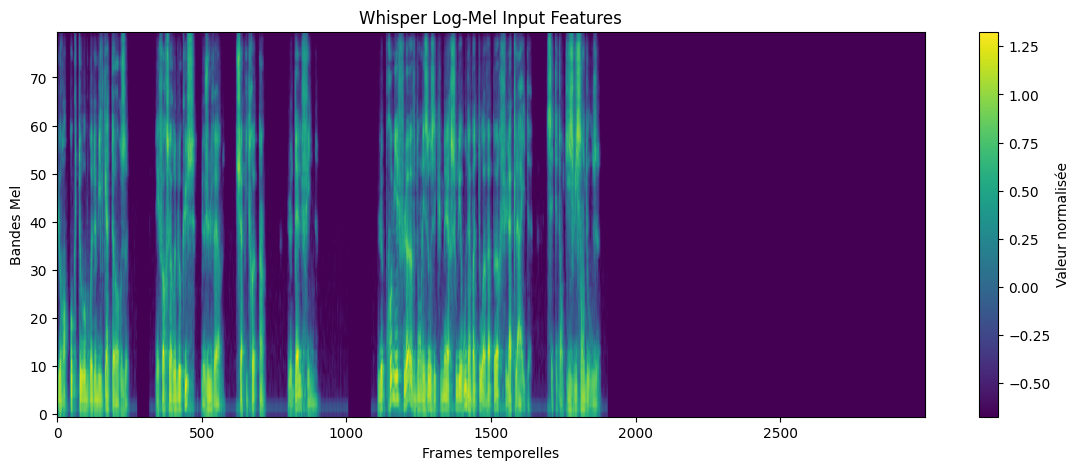

In [8]:
whisper_features = input_features[0].numpy()

plt.figure(figsize=(14, 5))

plt.imshow(
    whisper_features,
    aspect="auto",
    origin="lower"
)

plt.title("Whisper Log-Mel Input Features")
plt.xlabel("Frames temporelles")
plt.ylabel("Bandes Mel")
plt.colorbar(label="Valeur normalisée")

plt.show()

## 5. Chargement du modèle Whisper

Le `WhisperProcessor` prépare les entrées audio et gère le tokenizer.

Le modèle `WhisperForConditionalGeneration` contient ensuite :

- l'encoder, qui analyse les features audio ;
- le decoder, qui génère la transcription token par token.

In [9]:
model = WhisperForConditionalGeneration.from_pretrained(
    model_name
)

print("Modèle chargé :", model_name)
print("Type :", type(model).__name__)

Modèle chargé : openai/whisper-tiny
Type : WhisperForConditionalGeneration


## 6. Inspection de l'architecture Whisper

Whisper est un modèle encoder-decoder.

L'encoder reçoit les features audio et produit des représentations internes.

Le decoder utilise ensuite ces représentations pour générer les tokens de transcription.

In [10]:
encoder = model.model.encoder
decoder = model.model.decoder

print("Encoder :", type(encoder).__name__)
print("Decoder :", type(decoder).__name__)

print("\nNombre de couches encoder :", len(encoder.layers))
print("Nombre de couches decoder :", len(decoder.layers))

Encoder : WhisperEncoder
Decoder : WhisperDecoder

Nombre de couches encoder : 4
Nombre de couches decoder : 4


## 7. Passage dans l'encoder

L'encoder transforme le log-Mel spectrogram en représentations internes de l'audio.

Ces représentations seront ensuite utilisées par le decoder via la cross-attention.

In [11]:
with torch.no_grad():
    encoder_outputs = encoder(input_features)

hidden_states = encoder_outputs.last_hidden_state

print("Shape des représentations encoder :", hidden_states.shape)

Shape des représentations encoder : torch.Size([1, 1500, 384])


1     = batch size
1500  = positions temporelles après réduction
384   = dimension cachée du modèle Whisper Tiny

## 8. Génération des tokens

Le decoder utilise les représentations produites par l'encoder pour générer la transcription de manière autoregressive.

Chaque nouveau token dépend :

- des représentations audio de l'encoder ;
- des tokens déjà générés.

In [12]:
generated_ids = model.generate(
    input_features,
    language="fr",
    task="transcribe"
)

print("Shape des tokens générés :", generated_ids.shape)
print("IDs des premiers tokens :", generated_ids[0][:20])

The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


Shape des tokens générés : torch.Size([1, 67])
IDs des premiers tokens : tensor([43941, 13350,  2851,  1398,   368,  8227,    13,  3790,   337,   405,
          374,   476,  1749,  1149,    11,   476,   361,   425,   331,   716])


## 9. Décodage des tokens

Le decoder ne produit pas directement du texte lisible.

Il génère une séquence d'identifiants numériques de tokens.

Nous allons utiliser le tokenizer de Whisper pour convertir ces IDs en transcription.

In [13]:
transcription = processor.tokenizer.batch_decode(
    generated_ids,
    skip_special_tokens=True
)[0]

print("Transcription :")
print(transcription)

Transcription :
 durant octôme de 2014. Et forseur le blocus, le julverne, chapitre 1, le delfine. Le premier fleuve dont les oséquumères sous les roues d'un bateau avapur fut la clade, cet étendu 800 douze.


## 10. Tokens spéciaux de Whisper

Whisper utilise des tokens spéciaux pour contrôler la génération.

Ils peuvent notamment indiquer :

- le début d'une transcription ;
- la langue de l'audio ;
- la tâche à effectuer (`transcribe` ou `translate`) ;
- l'utilisation ou non des timestamps.

In [14]:
special_tokens = processor.tokenizer.all_special_tokens

print("Nombre de tokens spéciaux :", len(special_tokens))
print("\nQuelques tokens spéciaux :")

for token in special_tokens[:20]:
    print(token)

Nombre de tokens spéciaux : 107

Quelques tokens spéciaux :
<|endoftext|>
<|startoftranscript|>
<|en|>
<|zh|>
<|de|>
<|es|>
<|ru|>
<|ko|>
<|fr|>
<|ja|>
<|pt|>
<|tr|>
<|pl|>
<|ca|>
<|nl|>
<|ar|>
<|sv|>
<|it|>
<|id|>
<|hi|>


## 11. Prompt de génération Whisper

Whisper utilise des tokens spéciaux au début du décodage pour indiquer au decoder :

- la langue ;
- la tâche ;
- et éventuellement la gestion des timestamps.

In [15]:
decoder_prompt_ids = processor.get_decoder_prompt_ids(
    language="fr",
    task="transcribe"
)

print("Decoder prompt IDs :")
print(decoder_prompt_ids)

print("\nTokens correspondants :")

for position, token_id in decoder_prompt_ids:
    token = processor.tokenizer.convert_ids_to_tokens(token_id)
    print(position, token_id, "->", token)

Decoder prompt IDs :
[(1, 50265), (2, 50359), (3, 50363)]

Tokens correspondants :
1 50265 -> <|fr|>
2 50359 -> <|transcribe|>
3 50363 -> <|notimestamps|>


"Le contenu est en français"
→ "je dois transcrire"
→ "sans timestamps"

## 12. Préparation d'un exemple de fine-tuning

Pour fine-tuner Whisper, chaque exemple du dataset doit contenir :

- un signal audio ;
- sa transcription correcte.

L'audio sera transformé en `input_features`.

La transcription sera transformée en tokens appelés `labels`.

Pendant l'entraînement, le modèle comparera les tokens prédits aux `labels` afin de calculer la loss.

In [16]:
reference_text = """
Durant Octobre 2014, Les Forceurs de blocus de Jules Verne, chapitre 1, Le Delphin.
Le premier fleuve dont les eaux écumèrent sous les roues d’un bateau à vapeur fut la Clyde. C’était en 1812.
"""

print(reference_text)


Durant Octobre 2014, Les Forceurs de blocus de Jules Verne, chapitre 1, Le Delphin.
Le premier fleuve dont les eaux écumèrent sous les roues d’un bateau à vapeur fut la Clyde. C’était en 1812.



## 13. Tokenisation de la transcription

Pendant le fine-tuning, la transcription correcte doit être convertie en tokens.

Ces tokens deviennent les `labels` utilisés par le modèle pour calculer la loss.

In [17]:
label_ids = processor.tokenizer(
    reference_text,
    return_tensors="pt"
).input_ids

print("Shape des labels :", label_ids.shape)
print("Premiers IDs :", label_ids[0][:20])

Shape des labels : torch.Size([1, 76])
Premiers IDs : tensor([50258, 50265, 50359, 50363,   198,    35,   374,   394,  6788,   996,
          265,  8227,    11,  6965, 10580,  2156,   368,  1749,  1149,   368])


50258 → <|startoftranscript|>
50265 → <|fr|>
50359 → <|transcribe|>
50363 → <|notimestamps|>

In [18]:
decoded_labels = processor.tokenizer.decode(
    label_ids[0],
    skip_special_tokens=False
)

print(decoded_labels)

<|startoftranscript|><|fr|><|transcribe|><|notimestamps|>
Durant Octobre 2014, Les Forceurs de blocus de Jules Verne, chapitre 1, Le Delphin.
Le premier fleuve dont les eaux écumèrent sous les roues d’un bateau à vapeur fut la Clyde. C’était en 1812.
<|endoftext|>


In [19]:
decoded_text_only = processor.tokenizer.decode(
    label_ids[0],
    skip_special_tokens=True
)

print("\nTexte sans tokens spéciaux :")
print(decoded_text_only)


Texte sans tokens spéciaux :

Durant Octobre 2014, Les Forceurs de blocus de Jules Verne, chapitre 1, Le Delphin.
Le premier fleuve dont les eaux écumèrent sous les roues d’un bateau à vapeur fut la Clyde. C’était en 1812.



## 14. Préparation des labels pour l'entraînement

Pendant le fine-tuning, les séquences de texte n'ont pas toutes la même longueur.

Elles sont donc paddées pour former des batches.

Les positions de padding sont généralement remplacées par `-100`, afin qu'elles soient ignorées lors du calcul de la loss.

In [20]:
labels = label_ids.clone()

pad_token_id = processor.tokenizer.pad_token_id

labels[labels == pad_token_id] = -100

print("Pad token ID :", pad_token_id)
print("Shape des labels :", labels.shape)
print("Nombre de positions ignorées :", (labels == -100).sum().item())

Pad token ID : 50257
Shape des labels : torch.Size([1, 76])
Nombre de positions ignorées : 1


In [21]:
print("Pad token ID :", processor.tokenizer.pad_token_id)
print("EOS token ID :", processor.tokenizer.eos_token_id)

print(
    "Même ID ?",
    processor.tokenizer.pad_token_id == processor.tokenizer.eos_token_id
)

Pad token ID : 50257
EOS token ID : 50257
Même ID ? True


## 15. Padding d'un batch de transcriptions

Dans un vrai dataset, les transcriptions n'ont pas toutes la même longueur.

Le tokenizer ajoute donc du padding pour obtenir des séquences de même taille.

Nous allons utiliser `attention_mask` pour distinguer :

- les vrais tokens ;
- les positions ajoutées uniquement pour le padding.

Seules les positions de padding seront remplacées par `-100` dans les labels.

In [22]:
texts = [
    "Il fera beau demain.",
    "Une perturbation arrivera par l'ouest avec des pluies dans l'après-midi."
]

batch = processor.tokenizer(
    texts,
    padding=True,
    return_tensors="pt",
    return_attention_mask=True
)

print("Input IDs shape :", batch.input_ids.shape)
print("Attention mask shape :", batch.attention_mask.shape)

print("\nInput IDs :")
print(batch.input_ids)

print("\nAttention mask :")
print(batch.attention_mask)

Input IDs shape : torch.Size([2, 28])
Attention mask shape : torch.Size([2, 28])

Input IDs :
tensor([[50258, 50265, 50359, 50363, 37961, 50169, 29891, 44389,    13, 50257,
         50257, 50257, 50257, 50257, 50257, 50257, 50257, 50257, 50257, 50257,
         50257, 50257, 50257, 50257, 50257, 50257, 50257, 50257],
        [50258, 50265, 50359, 50363,    52,   716, 40468,   399, 34142,    64,
           971,   287,     6,   263,   377,  4163,   730, 44373,   530,  2680,
           287,     6, 48240,    12,    76, 12716,    13, 50257]])

Attention mask :
tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1, 1]])


In [23]:
labels = batch.input_ids.clone()

labels[batch.attention_mask == 0] = -100

print("Labels après masquage :")
print(labels)

print("\nNombre de positions ignorées :", (labels == -100).sum().item())

Labels après masquage :
tensor([[50258, 50265, 50359, 50363, 37961, 50169, 29891, 44389,    13, 50257,
          -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,
          -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100],
        [50258, 50265, 50359, 50363,    52,   716, 40468,   399, 34142,    64,
           971,   287,     6,   263,   377,  4163,   730, 44373,   530,  2680,
           287,     6, 48240,    12,    76, 12716,    13, 50257]])

Nombre de positions ignorées : 18


## 16. Calcul de la loss

Pendant l'entraînement, Whisper reçoit :

- les `input_features` provenant de l'audio ;
- les `labels` provenant de la transcription correcte.

Le modèle compare les tokens qu'il prédit aux labels attendus et calcule une loss.

Cette loss sera ensuite utilisée pour la backpropagation lors du fine-tuning.

In [24]:
training_labels = label_ids.clone()

outputs = model(
    input_features=input_features,
    labels=training_labels
)

print("Loss :", outputs.loss.item())
print("Logits shape :", outputs.logits.shape)

Loss : 3.5309576988220215
Logits shape : torch.Size([1, 76, 51865])


1      = batch size
76     = nombre de positions/tokens de la transcription
51865  = taille du vocabulaire possible à chaque position

## 17. Backpropagation

Lors du fine-tuning, la loss sert à calculer les gradients.

Ces gradients indiquent dans quelle direction les paramètres du modèle doivent être modifiés pour réduire l'erreur.

Le cycle d'entraînement est donc :

```text
input_features + labels
→ forward pass
→ loss
→ backward pass
→ gradients
→ mise à jour des paramètres

In [25]:
model.zero_grad()

outputs = model(
    input_features=input_features,
    labels=training_labels
)

loss = outputs.loss

loss.backward()

print("Loss :", loss.item())

first_parameter = next(model.parameters())

print(
    "Gradient disponible :",
    first_parameter.grad is not None
)

Loss : 3.5309576988220215
Gradient disponible : True


## 18. Mise à jour des paramètres

Après la backpropagation, les gradients sont disponibles.

Un optimizer utilise ces gradients pour modifier les paramètres du modèle afin de réduire progressivement la loss.

Le cycle complet devient :

```text
forward pass
→ loss
→ backward pass
→ gradients
→ optimizer.step()
→ paramètres mis à jour

In [27]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-5
)

optimizer.zero_grad()

outputs = model(
    input_features=input_features,
    labels=training_labels
)

loss = outputs.loss

loss.backward()
optimizer.step()

print("Étape d'entraînement effectuée")
print("Loss :", loss.item())

Étape d'entraînement effectuée
Loss : 3.5309576988220215


In [28]:
with torch.no_grad():
    outputs_after = model(
        input_features=input_features,
        labels=training_labels
    )

loss_after = outputs_after.loss.item()

print("Loss avant update :", loss.item())
print("Loss après update :", loss_after)

Loss avant update : 3.5309576988220215
Loss après update : 2.886807441711426


## 19. Vers un vrai fine-tuning

Un vrai fine-tuning ne consiste pas à entraîner Whisper sur un seul exemple.

Il faut utiliser un dataset contenant de nombreux couples :

```text
audio → transcription correcte

## 20. Paramètres du modèle

Le coût d'un fine-tuning dépend en grande partie du nombre de paramètres entraînables.

Nous allons compter :

- le nombre total de paramètres de Whisper Tiny ;
- le nombre de paramètres actuellement entraînables.

In [29]:
total_params = sum(
    p.numel() for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(f"Paramètres totaux : {total_params:,}")
print(f"Paramètres entraînables : {trainable_params:,}")

print(
    "Pourcentage entraînable :",
    f"{100 * trainable_params / total_params:.2f}%"
)

Paramètres totaux : 37,760,640
Paramètres entraînables : 37,184,640
Pourcentage entraînable : 98.47%


In [30]:
frozen_params = [
    (name, param.numel())
    for name, param in model.named_parameters()
    if not param.requires_grad
]

print("Paramètres gelés :")

for name, count in frozen_params:
    print(f"{name:50s} {count:,}")

print(
    "\nTotal gelé :",
    f"{sum(count for _, count in frozen_params):,}"
)

Paramètres gelés :
model.encoder.embed_positions.weight               576,000

Total gelé : 576,000


## 21. Full Fine-Tuning vs LoRA

Dans notre configuration actuelle, environ **98,47 %** des paramètres de Whisper Tiny sont entraînables.

Un full fine-tuning doit donc stocker et mettre à jour les gradients de presque tout le modèle, ce qui demande beaucoup de mémoire et de calcul.

LoRA adopte une approche différente :

```text
Full fine-tuning
Whisper
████████████████████
presque tous les paramètres entraînés

LoRA
Whisper
████████████████████  gelé

Adaptateurs LoRA
██                    entraînés

## 22. Conclusion

Dans ce notebook, nous avons ouvert la boîte noire de Whisper et étudié son fonctionnement interne.

Nous avons vu comment :

- `WhisperProcessor` transforme l'audio en features log-Mel ;
- l'encoder transforme ces features en représentations audio ;
- le decoder génère les tokens de manière autoregressive ;
- les tokens spéciaux contrôlent la langue, la tâche et les timestamps ;
- une transcription correcte est transformée en `labels` pour le fine-tuning ;
- le padding doit être masqué avec `-100` lors du calcul de la loss ;
- la loss permet de calculer les gradients par backpropagation ;
- un optimizer peut ensuite mettre à jour les paramètres du modèle ;
- un full fine-tuning entraîne presque tous les paramètres de Whisper Tiny ;
- LoRA permettrait d'adapter le modèle avec beaucoup moins de paramètres entraînables.

### Pipeline étudié

```text
Audio
→ WhisperProcessor
→ Log-Mel features
→ Encoder
→ Decoder
→ Tokens
→ Transcription